<a href="https://colab.research.google.com/github/vishnuwadkar/Machine-Learning/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression

#### Simple Linear regression: y = bo + b1x
#### Multiple Linear regression: y = bo + b1x1 + b2x2 + ....

## Conditions/Assupmtions for Linear regression
#### Linearity : x increases/decreases with y
#### Independence : No two datapoints dependent on each other
#### Homoscedacity : Residuals should constant (errors)
#### Normality: Residuals should follow normal distribution


## Evaluating Linear regression model

1.  Mean Absolute Error
2.  Mean Squared Error (helps in punishing large errors)
3. Root mean squared error
4. R-squared error (Coeff. of determination)n



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
import copy
import seaborn as sns
import tensorflow as tf
from sklearn.linear_model import LinearRegression

In [17]:
dataset_cols = ["bike_count", "hour", "temp", "humidity", "wind", "visibility", "dew_pt_temp", "radiation", "rain", "snow", "functional"]
df = pd.read_csv('SeoulBikeData.csv').drop(['Date','Holiday','Seasons'], axis = 1)

In [28]:
df.columns = dataset_cols
df['functional'] = (df['functional'] == 'Yes').astype(int)
df = df[df['hour'] == 12]
df.drop(['hour'], axis = 1)

,bike_count,temp,humidity,wind,visibility,dew_pt_temp,radiation,rain,snow,functional
12,449,1.7,23,1.4,2000,-17.2,1.11,0.0,0.0,0
36,479,4.3,41,1.3,1666,-7.8,1.09,0.0,0.0,0
60,333,5.8,85,1.7,349,3.4,0.43,0.0,0.0,0
84,393,-0.3,38,4.8,1823,-12.9,1.11,0.0,0.0,0
108,321,-2.3,25,0.0,1962,-19.7,0.00,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...
8652,752,9.1,57,1.1,562,1.0,1.69,0.0,0.0,0
8676,672,9.3,61,1.5,390,2.1,0.85,0.0,0.0,0
8700,635,7.9,14,1.7,1688,-18.0,1.81,0.0,0.0,0
8724,661,5.6,27,0.3,1522,-11.9,0.34,0.0,0.0,0


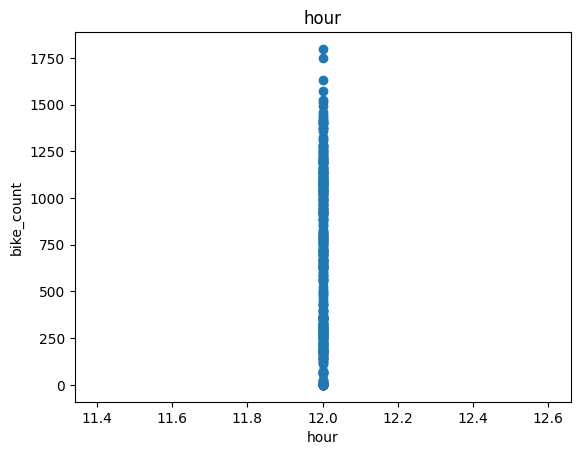

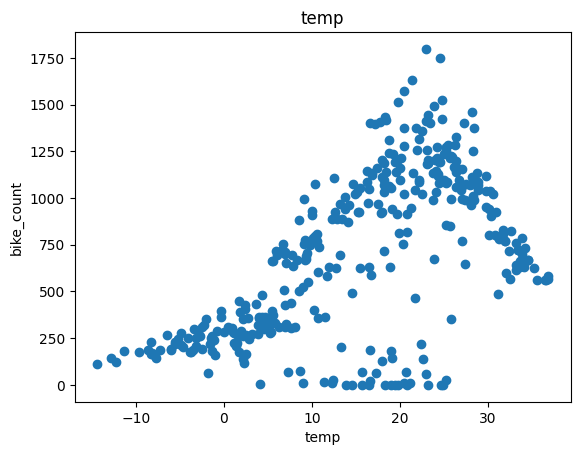

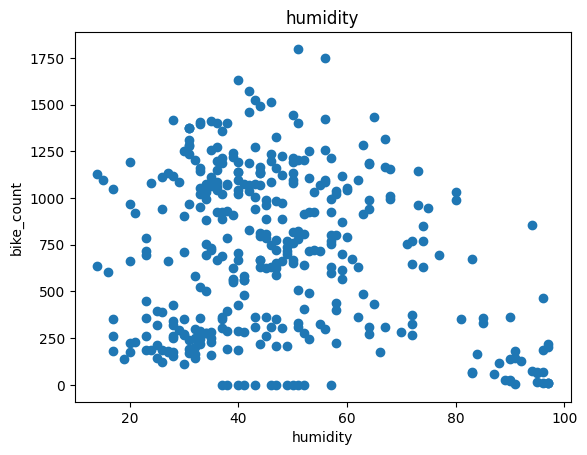

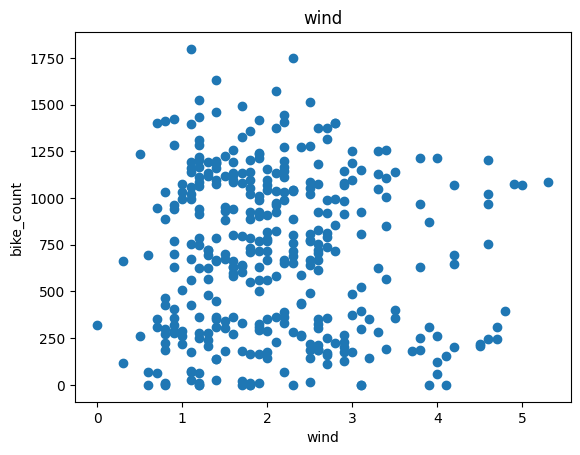

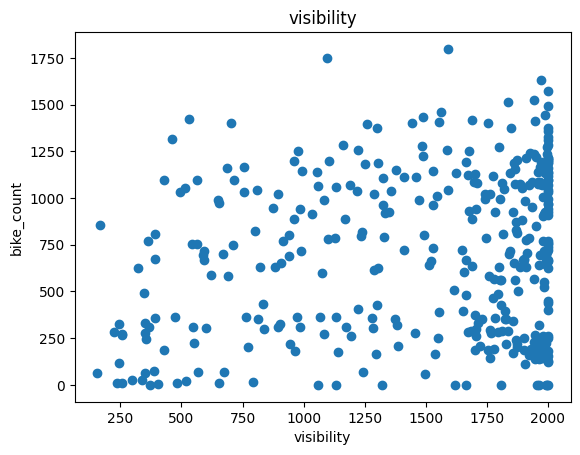

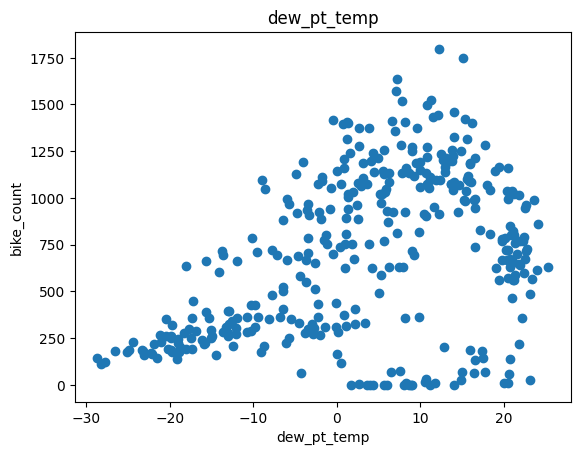

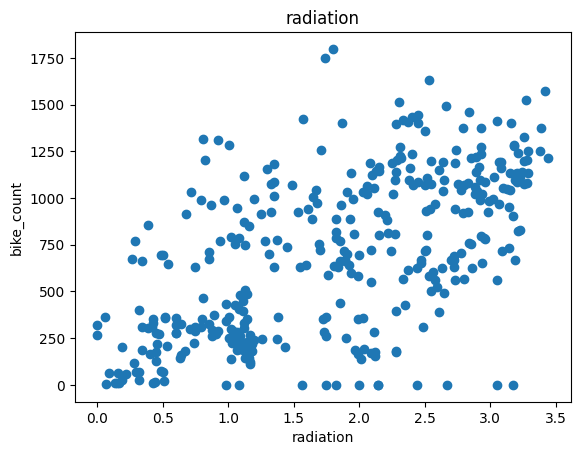

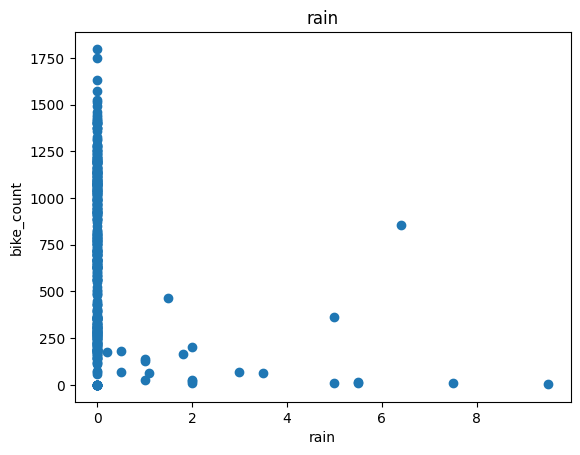

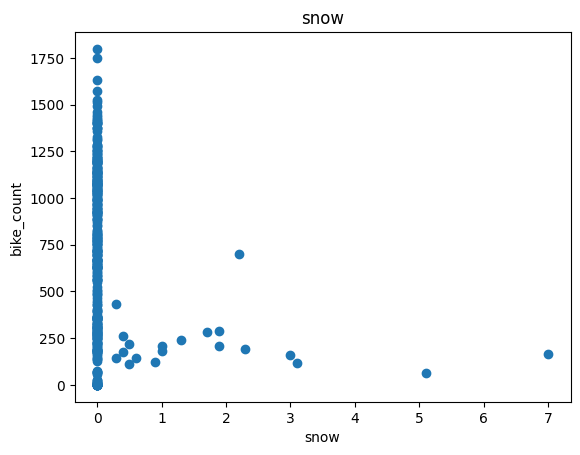

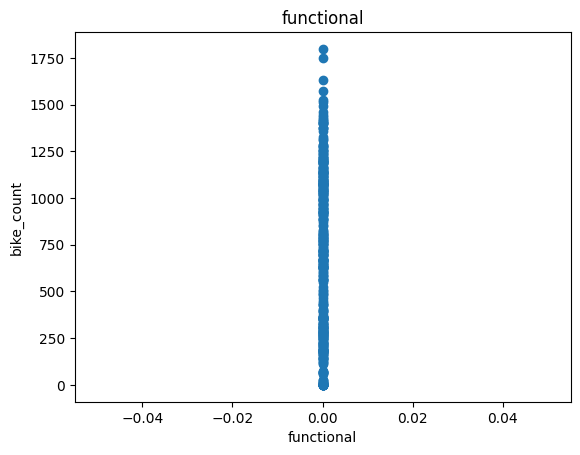

In [29]:
for label in df.columns[1:]:
  plt.scatter(df[label], df['bike_count'])
  plt.xlabel(label)
  plt.ylabel('bike_count')
  plt.title(label)
  plt.show()

In [30]:
df.drop(['wind','visibility','functional'], axis = 1)

,bike_count,hour,temp,humidity,dew_pt_temp,radiation,rain,snow
12,449,12,1.7,23,-17.2,1.11,0.0,0.0
36,479,12,4.3,41,-7.8,1.09,0.0,0.0
60,333,12,5.8,85,3.4,0.43,0.0,0.0
84,393,12,-0.3,38,-12.9,1.11,0.0,0.0
108,321,12,-2.3,25,-19.7,0.00,0.0,0.0
...,...,...,...,...,...,...,...,...
8652,752,12,9.1,57,1.0,1.69,0.0,0.0
8676,672,12,9.3,61,2.1,0.85,0.0,0.0
8700,635,12,7.9,14,-18.0,1.81,0.0,0.0
8724,661,12,5.6,27,-11.9,0.34,0.0,0.0


### Splitting into training/validation/tesing

In [33]:
train, val, test = np.split(df.sample(frac = 1), [int(0.6 * len(df)), int(0.8 * len(df))])

In [49]:
def get_xy(dataframe, ylabel, xlabel=None):
  dataframe = copy.deepcopy(dataframe)
  if xlabel is None:
    X = dataframe[[c for c in dataframe.columns if c != ylabel]].values
  else:
    if len(xlabel) == 1:
      X = dataframe[xlabel].values.reshape(-1, 1)
    else:
      X = dataframe[xlabel].values
  y = dataframe[ylabel].values.reshape(-1,1)
  data = np.hstack([X,y])
  return data, X, y

In [50]:
_ , X_train_temp, y_train_temp = get_xy(train, 'bike_count', xlabel=['temp'])
_ , X_val_temp, y_val_temp = get_xy(val, 'bike_count', xlabel=['temp'])
_ , X_test_temp, y_test_temp = get_xy(test, 'bike_count', xlabel=['temp'])

#### Temperature regressor that only uses temperature data

In [51]:
temp_regressor = LinearRegression()
temp_regressor.fit(X_train_temp, y_train_temp)

LinearRegression()

In [52]:
print(temp_regressor.coef_)
print(temp_regressor.intercept_)

[[22.72271353]]
[360.99402281]


In [53]:
temp_regressor.score(X_test_temp, y_test_temp)   #R-squared score that tells the association between the two variables

0.22011449484979695

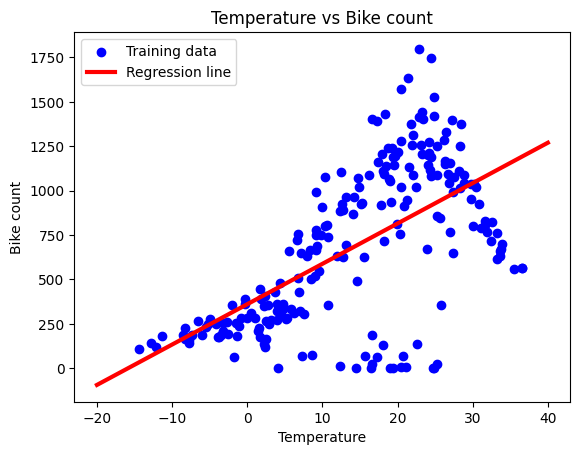

In [54]:
plt.scatter(X_train_temp, y_train_temp, color = 'blue', label = 'Training data')
X = tf.linspace(-20,40,100)
plt.plot(X, temp_regressor.predict(np.array(X).reshape(-1,1)), color = 'red', label = 'Regression line',linewidth = 3)
plt.legend()
plt.xlabel('Temperature')
plt.ylabel('Bike count')
plt.title('Temperature vs Bike count')
plt.show()

In [55]:
_ , X_train_all, y_train_all = get_xy(train, 'bike_count', xlabel=df.columns[1:])
_ , X_val_all, y_val_all = get_xy(val, 'bike_count', xlabel=df.columns[1:])
_ , X_test_all, y_test_all = get_xy(test, 'bike_count', xlabel=df.columns[1:])

In [56]:
all_regressor = LinearRegression()
all_regressor.fit(X_train_all, y_train_all)

LinearRegression()

In [57]:
all_regressor.score(X_test_all, y_test_all)

0.3647603836612001